In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sdv.metadata import SingleTableMetadata as Metadata
import os
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition
from sdv.evaluation.single_table import evaluate_quality
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
import seaborn as sns
from xgboost import XGBClassifier
import pickle
from flask import Flask, request,jsonify
from werkzeug.utils import secure_filename

In [ ]:
data= pd.read_csv("creditcard.csv")
if data.isnull().sum().any():
    data.fillna(data.mean(),inplace=True)

scaler = MinMaxScaler()
data[['Time','Amount']]=scaler.fit_transform(data[['Time','Amount']])

In [ ]:
scaler_path="scaler.pkl"
with open(scaler_path,'wb')as f:
    pickle.dump(scaler,f)
print(f'Scaler saved to {scaler_path}')

Scaler saved to scaler.pkl


In [ ]:
# run_once_resave_scaler.py — run from Backend/ folder
import pickle
from sklearn.preprocessing import MinMaxScaler
import joblib

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

joblib.dump(scaler, "scaler.joblib")  # saves with current sklearn version
print("✓ Saved scaler.joblib")

In [ ]:
data['Class'] = data['Class'].astype(bool)

In [ ]:
metadata =Metadata()
metadata.detect_from_dataframe(data)
metadata.update_column(column_name='Time',sdtype ='numerical')
metadata.update_column(column_name='Amount',sdtype='numerical')
metadata.update_column(column_name='Class', sdtype='boolean')
for col in[f'V{i}' for i in range(1,29)]:
    metadata.update_column(column_name=col,sdtype='numerical')

In [ ]:
data.to_csv(f"preprocessed_creditcard.csv", index=False)
metadata.save_to_json(f"metadata.json")

In [ ]:
print("sample of preposcessed data:")
print(data.head())
print("\nMetadata:")
print(metadata.to_dict())

sample of preposcessed data:
       Time        V1        V2        V3        V4        V5        V6  \
0  0.000000 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1  0.000000  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2  0.000006 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3  0.000006 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4  0.000012 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0  0.239599  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928   
1 -0.078803  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846   
2  0.791461  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281   
3  0.237609  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575   
4  0.592941 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       V27       V

In [ ]:
data=pd.read_csv("preprocessed_creditcard.csv")
metadata=Metadata.load_from_json("metadata.json")

In [ ]:
synthesizer = CTGANSynthesizer(
    metadata,
    epochs=300,
    batch_size=500,
    generator_lr=0.0002,
    discriminator_lr=0.0002,
    pac=10,
    cuda=True  # Enable GPU
)

c:\Users\riddh\.conda\envs\torch-gpu\lib\site-packages\sdv\single_table\base.py:163: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


In [ ]:
print("Training CTGAN model...")
synthesizer.fit(data)
print("CTGAN model trained successfully.")

Training CTGAN model...
CTGAN model trained successfully.


In [ ]:
model_path = "ctgan_model.pkl"
synthesizer.save(model_path)
print(f"CTGAN model saved to {model_path}")

CTGAN model saved to ctgan_model.pkl


In [ ]:
model_path="ctgan_model.pkl"
synthesizer = CTGANSynthesizer.load(model_path)
data=pd.read_csv("preprocessed_creditcard.csv")

In [ ]:
num_rows = 10000
fraud_condition = Condition({'Class': True}, num_rows=5000)
legit_condition = Condition({'Class': False}, num_rows=5000)
synthetic_data = synthesizer.sample_from_conditions([fraud_condition, legit_condition])

Sampling conditions: 100%|██████████| 10000/10000 [00:03<00:00, 2534.40it/s]


In [ ]:
scaler= MinMaxScaler()
scaler.fit(data[['Time','Amount']])
synthetic_data[['Time','Amount']]=scaler.inverse_transform(synthetic_data[['Time','Amount']])

In [ ]:
synthetic_path = "synthetic_creditcard.csv"
synthetic_data.to_csv(synthetic_path,index=False)
print(f"Synthetic data saved to {synthetic_path}")

Synthetic data saved to synthetic_creditcard.csv


In [ ]:
print("sample of synthetic data:")
print(synthetic_data.head())
print(f"\nClass Distribution:\n{synthetic_data['Class'].value_counts()}")

sample of synthetic data:
       Time         V1        V2        V3        V4        V5        V6  \
0  0.069106  -0.648446  5.257461 -5.089180  3.870796 -0.794357 -1.179563   
1  0.033892  -1.574177  2.077632 -3.686755  1.044782 -1.575087 -0.708635   
2  0.446398 -12.379842  7.803719 -2.337896  7.560446  1.652853 -7.462985   
3  0.460657 -10.003067  7.074077 -8.692411  4.640614 -2.489818 -2.970781   
4  0.161491  -3.420439  2.797667 -4.625947  3.179440 -1.098708 -2.318469   

          V7        V8        V9  ...       V21       V22       V23       V24  \
0  -3.501927  0.209189 -1.733125  ...  0.875026 -0.068921  0.038023 -0.458759   
1  -3.617157  0.129786 -0.450418  ...  3.344765  0.989437 -0.255587  0.029072   
2  -1.415581  0.502287 -3.569981  ...  0.367141 -0.220690 -0.504147  0.857391   
3 -12.001797 -2.935732 -0.811815  ...  2.243705 -0.228808  0.170186 -0.800268   
4  -4.448784  0.986611 -1.842545  ...  0.641409 -0.479818  0.074985 -0.092606   

        V25       V26       V2

In [ ]:
print("Evaluating statistical fidelity...")
quality_report=evaluate_quality(data,synthetic_data,metadata)
print("Quality report:")
print(quality_report.get_details('Column Shapes'))

Evaluating statistical fidelity...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:02<00:00, 15.13it/s]|
Column Shapes Score: 79.42%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:27<00:00, 16.67it/s]|
Column Pair Trends Score: 85.76%

Overall Score (Average): 82.59%

Quality report:
    Column        Metric     Score
0     Time  KSComplement  0.934195
1       V1  KSComplement  0.791448
2       V2  KSComplement  0.780870
3       V3  KSComplement  0.716720
4       V4  KSComplement  0.621946
5       V5  KSComplement  0.790069
6       V6  KSComplement  0.795863
7       V7  KSComplement  0.703168
8       V8  KSComplement  0.852343
9       V9  KSComplement  0.748430
10     V10  KSComplement  0.645007
11     V11  KSComplement  0.670261
12     V12  KSComplement  0.685033
13     V13  KSComplement  0.939367
14     V14  KSComplement  0.589958
15     V15  KSComplement  0.952807
16     V16  KSComplement  0.772943
17     V17  KSComplement  0.766034
18  

In [ ]:
x_real =data.drop('Class',axis=1)
y_real=data['Class']
x_synthetic=synthetic_data.drop('Class',axis=1)
y_synthetic=synthetic_data['Class']

In [ ]:
x_train_real,x_test_real,y_train_real,y_test_real=train_test_split(x_real,y_real,test_size=0.2,random_state=42,stratify=y_real)

In [ ]:
clf=LogisticRegression(random_state=42,max_iter=1000)
clf.fit(x_synthetic,y_synthetic)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred=clf.predict(x_test_real)
fi=f1_score(y_test_real,y_pred)
auc_roc=roc_auc_score(y_test_real,clf.predict_proba(x_test_real)[:,1])

print(f"\nFraud Detection Performance:\nF1 Score: {fi:.4f}\nAUC-ROC: {auc_roc:.4f}")


Fraud Detection Performance:
F1 Score: 0.1227
AUC-ROC: 0.9763


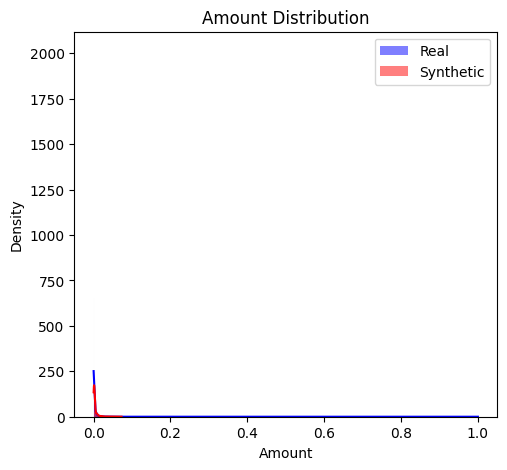

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

sns.histplot(data['Amount'], color='blue', label='Real', kde=True, stat='density')
sns.histplot(synthetic_data['Amount'], color='red', label='Synthetic', kde=True, stat='density')

plt.title("Amount Distribution")
plt.legend()

([<matplotlib.axis.XTick at 0x12d940dd480>,
 [Text(0, 0, 'False'), Text(1, 0, 'True')])

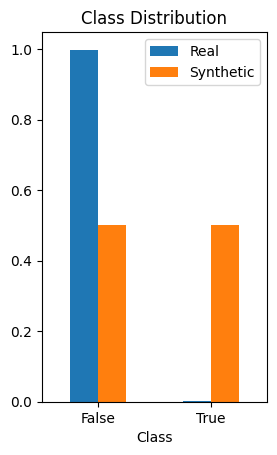

In [ ]:
plt.subplot(1,2,2)
real_class_counts=data['Class'].value_counts(normalize=True)
synthetic_class_counts=synthetic_data['Class'].value_counts(normalize=True)
pd.DataFrame({
    'Real':real_class_counts,
    'Synthetic':synthetic_class_counts
}).plot(kind='bar',ax=plt.gca())
plt.title("Class Distribution")
plt.xticks([0,1],['False','True'],rotation=0)

In [ ]:
x_synthetic = synthetic_data.drop('Class',axis=1)
y_synthetic = synthetic_data['Class'].astype(int)

In [ ]:
x_real =data.drop('Class',axis=1)
y_real=data['Class'].astype(int)
x_train_real,x_test_real,y_train_real,y_test_real=train_test_split(x_real,y_real,test_size=0.2,random_state=42,stratify=y_real)


In [ ]:
clf = XGBClassifier(random_state=42,eval_metric='logloss')
clf.fit(x_synthetic,y_synthetic)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
y_pred=clf.predict(x_test_real)
f1=f1_score(y_test_real,y_pred)
auc_roc=roc_auc_score(y_test_real,clf.predict_proba(x_test_real)[:,1])

print("Fraud Detection Performance:")
print(f"F1-score:{f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

Fraud Detection Performance:
F1-score:0.0929
AUC-ROC: 0.9826


In [ ]:
classifier_path = "fraud_classification.pkl"
with open(classifier_path,'wb') as f:
    pickle.dump(clf,f)
print(f"Classifier Saved to {classifier_path}")

Classifier Saved to fraud_classification.pkl


In [ ]:
app = Flask(__name__)
@app.route('/predict',methods=['POST'])
def predict():
    try:
        data=request.get_json()
        input_data = pd.DataFrame([data], columns=x_synthetic.columns) 
        prediction=clf.predict(input_data)[0]
        probability=clf.predict_proba(input_data)[0][1]
        return jsonify({
            'fraud': bool(prediction),
            'fraud_probability': float(probability)
        })
    except Exception as e:
        return jsonify({
            'error':str(e)
        }),400

In [ ]:
if __name__ == '__main__':
    import requests
    import threading
    import time

    # Start Flask server in a background thread
    thread = threading.Thread(target=lambda: app.run(debug=False, use_reloader=False))
    thread.daemon = True
    thread.start()

    # Give the server a moment to start up
    time.sleep(2)

    # Now safely make the request
    real_transaction = data.drop('Class', axis=1).iloc[0].to_dict()
    print("\nTesting API with real transaction:")
    print(f"Real transaction: {real_transaction}")
    print(f"Actual Class: {bool(data['Class'].iloc[0])}")

    response = requests.post('http://127.0.0.1:5000/predict', json=real_transaction)
    print("API Response:", response.json())

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit



Testing API with real transaction:
Real transaction: {'Time': 0.0, 'V1': -1.3598071336738, 'V2': -0.0727811733098497, 'V3': 2.53634673796914, 'V4': 1.37815522427443, 'V5': -0.338320769942518, 'V6': 0.462387777762292, 'V7': 0.239598554061257, 'V8': 0.0986979012610507, 'V9': 0.363786969611213, 'V10': 0.0907941719789316, 'V11': -0.551599533260813, 'V12': -0.617800855762348, 'V13': -0.991389847235408, 'V14': -0.311169353699879, 'V15': 1.46817697209427, 'V16': -0.470400525259478, 'V17': 0.207971241929242, 'V18': 0.0257905801985591, 'V19': 0.403992960255733, 'V20': 0.251412098239705, 'V21': -0.018306777944153, 'V22': 0.277837575558899, 'V23': -0.110473910188767, 'V24': 0.0669280749146731, 'V25': 0.128539358273528, 'V26': -0.189114843888824, 'V27': 0.133558376740387, 'V28': -0.0210530534538215, 'Amount': 0.0058237930868049}
Actual Class: False


127.0.0.1 - - [05/Apr/2026 14:24:07] "POST /predict HTTP/1.1" 200 -


API Response: {'fraud': False, 'fraud_probability': 6.619149644393474e-05}


127.0.0.1 - - [05/Apr/2026 14:24:46] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [05/Apr/2026 14:25:42] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [05/Apr/2026 14:26:40] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [05/Apr/2026 14:26:40] "POST /predict_batch HTTP/1.1" 404 -
127.0.0.1 - - [05/Apr/2026 14:55:43] "GET /health HTTP/1.1" 404 -
127.0.0.1 - - [05/Apr/2026 14:55:43] "GET /health HTTP/1.1" 404 -
127.0.0.1 - - [05/Apr/2026 14:55:45] "GET /health HTTP/1.1" 404 -
127.0.0.1 - - [05/Apr/2026 14:55:46] "GET /health HTTP/1.1" 404 -
127.0.0.1 - - [05/Apr/2026 14:55:46] "GET /health HTTP/1.1" 404 -
127.0.0.1 - - [05/Apr/2026 14:55:46] "GET /health HTTP/1.1" 404 -
127.0.0.1 - - [05/Apr/2026 14:55:54] "GET /health HTTP/1.1" 404 -
127.0.0.1 - - [05/Apr/2026 14:55:55] "GET /health HTTP/1.1" 404 -
127.0.0.1 - - [05/Apr/2026 14:55:57] "GET /health HTTP/1.1" 404 -
127.0.0.1 - - [05/Apr/2026 14:55:58] "GET /health HTTP/1.1" 404 -
127.0.0.1 - - [05/Apr/2026 14:56:07] "GET /health HTTP/1.1" 40

In [ ]:
classifier_path='fraud_classification.pkl'
with open(classifier_path,'rb') as f:
    clf=pickle.load(f)

In [ ]:
import pickle, xgboost as xgb

with open("fraud_classification.pkl", "rb") as f:
    model = pickle.load(f)

model.save_model("fraud_classification.ubj")
print("✓ Saved fraud_classification.ubj")

✓ Saved fraud_classification.ubj


In [ ]:
data=pd.read_csv('preprocessed_creditcard.csv')
feature_columns=data.drop('Class',axis=1).columns.tolist()

In [ ]:
scaler_path = "scaler.pkl"
scaler =None
if os.path.exists(scaler_path):
    with open(scaler_path, 'rb') as f:
        scaler =pickle.load(f)
else:
    print("scaler not found, re-fitting scaler...")
    raw_data_path='creditcard.csv'
    if os.path.exists(raw_data_path):
        raw_data=pd.read_csv(raw_data_path)
        scaler=MinMaxScaler()
        scaler.fit(raw_data[['Time','Amount']])
    else:
        scaler=MinMaxScaler()
        scaler.fit(data[['Time','Amount']])
    with open(scaler_path,'wb') as f:
        pickle.dump(scaler,f)
    print(f"Scaler saved to {scaler_path}")

In [ ]:
project_dir = r"C:\Users\riddh\Desktop\Sem 4\Machine Learning\project\AI_synthetic_data"
app = Flask(__name__)
app.config["UPLOAD_FOLDER"]=project_dir
ALLOWED_EXTENSIONS = {'csv'}

def allowed_file(filename):
    return '.' in filename and filename.rsplit('.',1)[1] .lower() in ALLOWED_EXTENSIONS

def preprocess_transaction(data,scaler=None):
    df=pd.DataFrame([data],columns=feature_columns)
    if scaler and (df['Time'].max() >1.0 or df['Amount'].max()>1.0):
        data[['Time','Amount']]=scaler.transform(data[['Time','Amount']])
    return data

def preprocess_batch(data,scaler=None):
    if scaler and (data['Time'].max()>1.0 or data['Amount'].max()>1.0):
        data[['Time','Amount']]=scaler.transform(data[['Time','Amount']])
    return data

@app.route('/predict',methods=['POST'])
def predict():
    try:
        data=request.get_json()
        input_data=preprocess_transaction(data,scaler)
        prediction=clf.predict(input_data)[0]
        probability=clf.predict_proba(input_data)[0][1]
        return jsonify({
            'fraud': bool(prediction),
            'fraud_probability':float(probability)
        })
    except Exception as e:
        return jsonify({'error': str(e)}),400
    
@app.route('/predict_batch',methods=['POST'])
def predict_batch():
    try:
        if 'file' not in request.file:
            return jsonify({'error':'No file provivded'}),400
        file = request.files['file']
        if file.filename =='':
            return jsonify({'error': "No file selected"}),400
        if file and allowed_file(file.filename):
            filename=secure_filename(file.filename)
            file_path=os.path.join(app.config['UPLOAD_FOLDER'],filename)
            file.save(file_path)
            data1 = pd.read_csv(file_path)
            
            missing_cols=[col for col in feature_columns if col not in data1.columns]
            if missing_cols:
                return jsonify({"error":f"Missing columns:{missing_cols}"}),400
            
            input_data = preprocess_batch(data[feature_columns], scaler)
            predictions=clf.predict(input_data)
            probabilities=clf.predict_proba(input_data)[:,1]
            output_data=data1.copy()
            output_data['Predicted_Class']=predictions.astype(bool)
            output_data['Fraud_probability']=probabilities
            output_path='batch_predictions.csv'
            output_data.to_csv(output_path,index=False)

            metrics={}
            if 'Class' in data1.columns:
                f1=f1_score(data["Class"].astype(int),predictions)
                auc_roc=roc_auc_score(data["Class"].astype(int),probabilities)
                metrics={ 
                    'f1_score':float(f1),
                    'auc-roc':float(auc_roc)
                }
            return jsonify({
                'predictions_saved':output_path,
                'metrics':metrics
            })
        else:
            return jsonify({'error':'Invalid File format , use csv'}),400
    except Exception as e:
        return jsonify({'error':str(e)}),400

In [ ]:
if __name__ == '__main__':
    import requests
    import threading
    import time

    # Start Flask server in background thread first
    thread = threading.Thread(target=lambda: app.run(debug=False, use_reloader=False))
    thread.daemon = True
    thread.start()
    time.sleep(2)  # Wait for server to start

    # Single transaction test
    real_transaction = data.drop('Class', axis=1).iloc[0].to_dict()
    print("\nTesting API with single real transaction:")
    print(f"Real transaction: {real_transaction}")
    print(f"Actual Class: {bool(data['Class'].iloc[0])}")

    response = requests.post('http://127.0.0.1:5000/predict', json=real_transaction)
    print('API Response:', response.json())

    # Batch test
    batch_data = data.head(5)[feature_columns + ["Class"]]  # Fix: head() not hand()
    batch_path = 'test_batch.csv'
    batch_data.to_csv(batch_path, index=False)              # Fix: batch_path not batch_data
    print("\nTesting API with batch of 5 real transactions:")
    print(f"Batch saved to {batch_path}")

    with open(batch_path, 'rb') as f:
        response = requests.post('http://127.0.0.1:5000/predict_batch', files={'file': f})
    print("Batch API Response:", response.json())